# Power Transform

| Feature                            | Function Transformer | Power Transformer |
| ---------------------------------- | -------------------- | ----------------- |
| Manual or Automatic                | Manual               | Automatic         |
| Intelligence                       | Low                  | High              |
| Best for                           | Known skew           | Unknown skew      |
| Custom functions                   | Yes                  | No                |
| Automatically finds best transform | No                   | Yes               |
| Simplicity                         | Easy                 | Moderate          |
| Interpretability                   | High                 | Medium            |


 >________

| Technique                  | Works With                        |
| -------------------------- | --------------------------------- |
| Box-Cox Transformation     | Only positive values              |
| Yeo-Johnson Transformation | Positive + negative + zero values |


In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
import scipy.stats as stats
from sklearn.preprocessing import PowerTransformer

# Box - Cox

In [5]:
df = pd.read_csv('/content/sample_data/concrete_data (1).csv')

df

,Cement,Blast Furnace Slag,Fly Ash,Water,Superplasticizer,Coarse Aggregate,Fine Aggregate,Age,Strength
0,540.0,0.0,0.0,162.0,2.5,1040.0,676.0,28,79.99
1,540.0,0.0,0.0,162.0,2.5,1055.0,676.0,28,61.89
2,332.5,142.5,0.0,228.0,0.0,932.0,594.0,270,40.27
3,332.5,142.5,0.0,228.0,0.0,932.0,594.0,365,41.05
4,198.6,132.4,0.0,192.0,0.0,978.4,825.5,360,44.30
...,...,...,...,...,...,...,...,...,...
1025,276.4,116.0,90.3,179.6,8.9,870.1,768.3,28,44.28
1026,322.2,0.0,115.6,196.0,10.4,817.9,813.4,28,31.18
1027,148.5,139.4,108.6,192.7,6.1,892.4,780.0,28,23.70
1028,159.1,186.7,0.0,175.6,11.3,989.6,788.9,28,32.77


In [6]:
df.describe()

,Cement,Blast Furnace Slag,Fly Ash,Water,Superplasticizer,Coarse Aggregate,Fine Aggregate,Age,Strength
count,1030.000000,1030.000000,1030.000000,1030.000000,1030.000000,1030.000000,1030.000000,1030.000000,1030.000000
mean,281.167864,73.895825,54.188350,181.567282,6.204660,972.918932,773.580485,45.662136,35.817961
std,104.506364,86.279342,63.997004,21.354219,5.973841,77.753954,80.175980,63.169912,16.705742
min,102.000000,0.000000,0.000000,121.800000,0.000000,801.000000,594.000000,1.000000,2.330000
25%,192.375000,0.000000,0.000000,164.900000,0.000000,932.000000,730.950000,7.000000,23.710000
50%,272.900000,22.000000,0.000000,185.000000,6.400000,968.000000,779.500000,28.000000,34.445000
75%,350.000000,142.950000,118.300000,192.000000,10.200000,1029.400000,824.000000,56.000000,46.135000
max,540.000000,359.400000,200.100000,247.000000,32.200000,1145.000000,992.600000,365.000000,82.600000


## seperate tar&Feat col

In [7]:
X = df.drop(columns=["Strength"])
y = df.iloc[:,-1]

In [8]:
X_train,X_test,y_train,y_test = train_test_split(
    X,y,test_size=0.2,random_state=42
)

## visualize without transformations

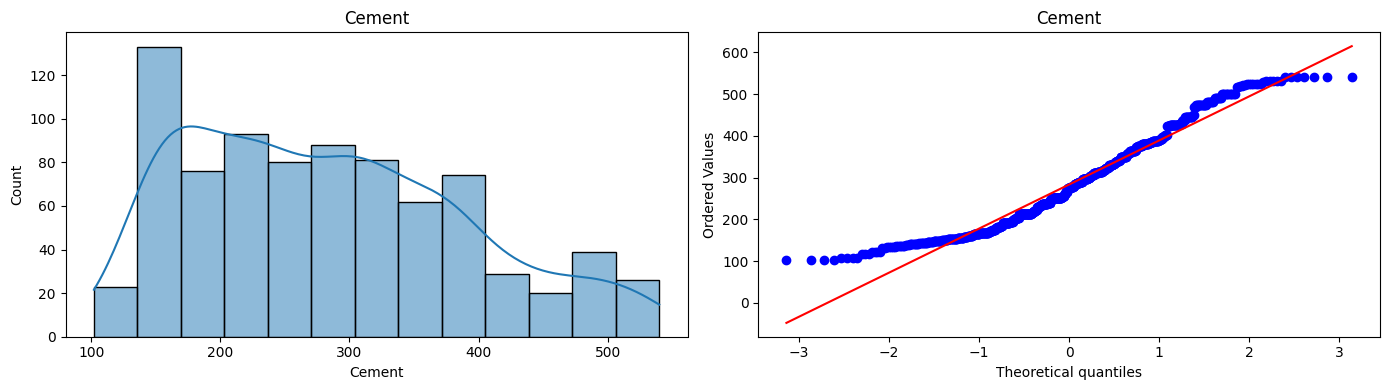

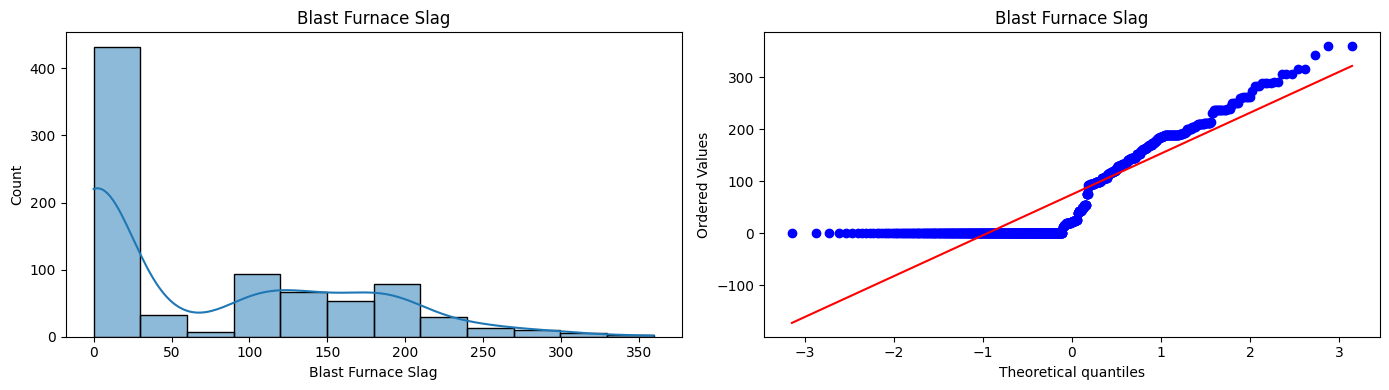

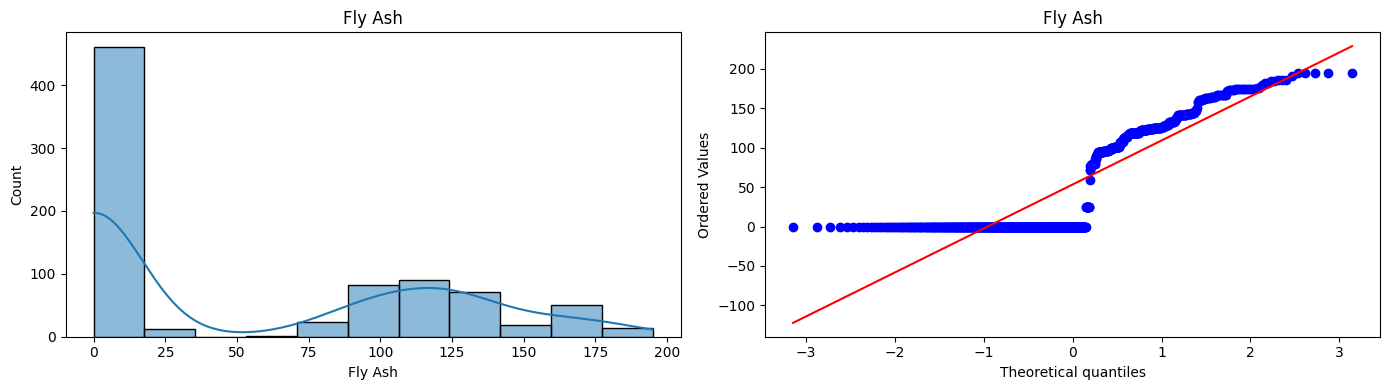

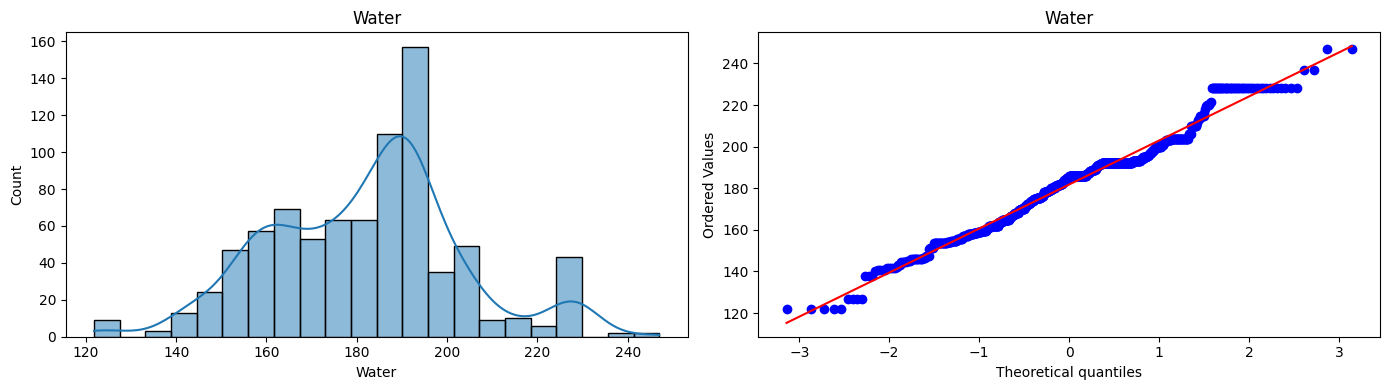

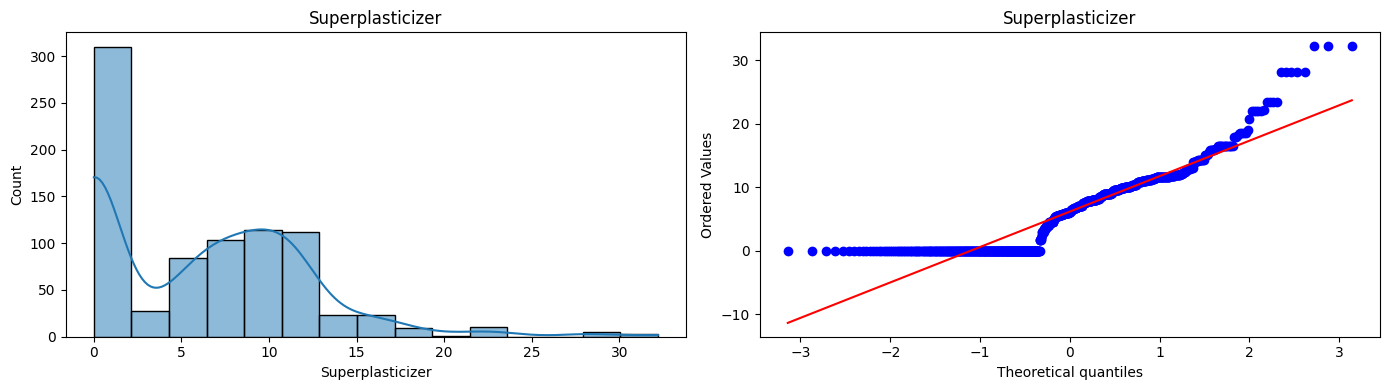

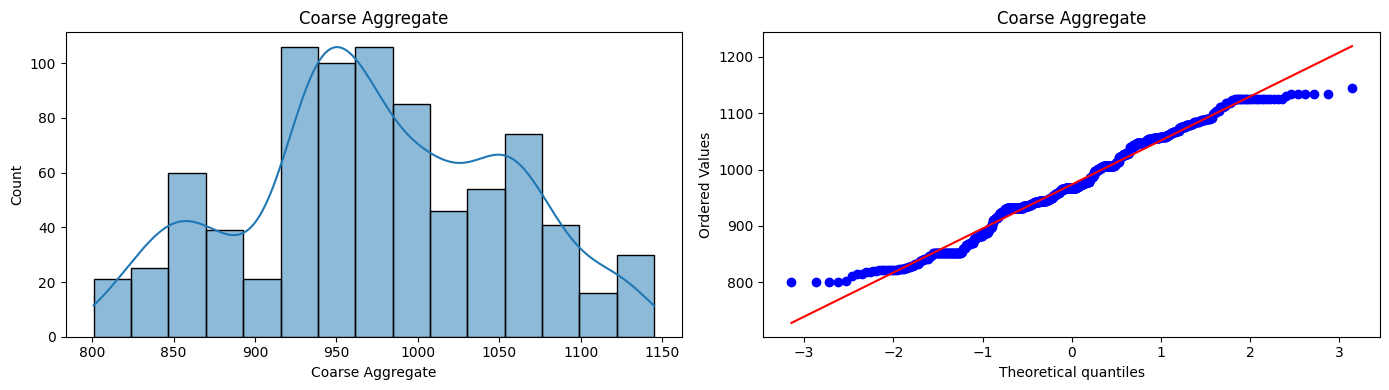

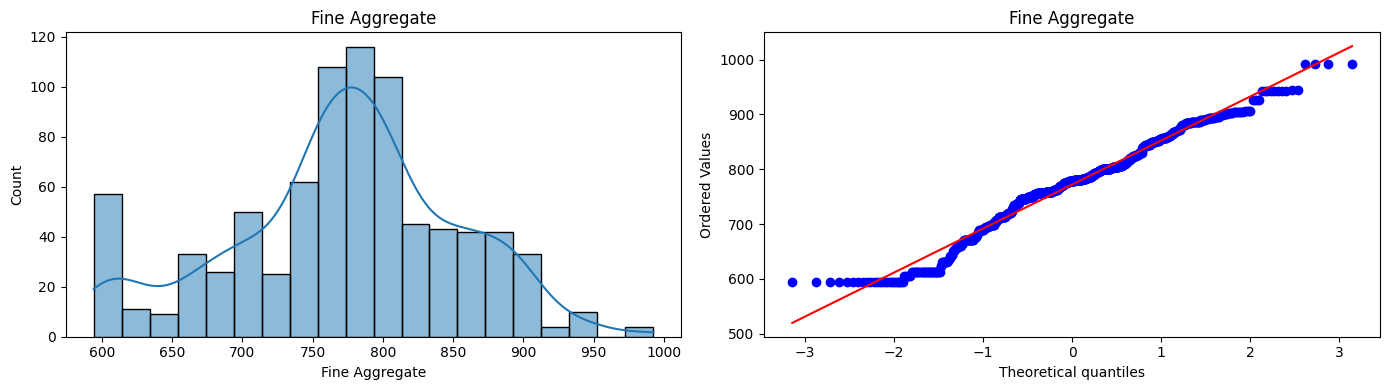

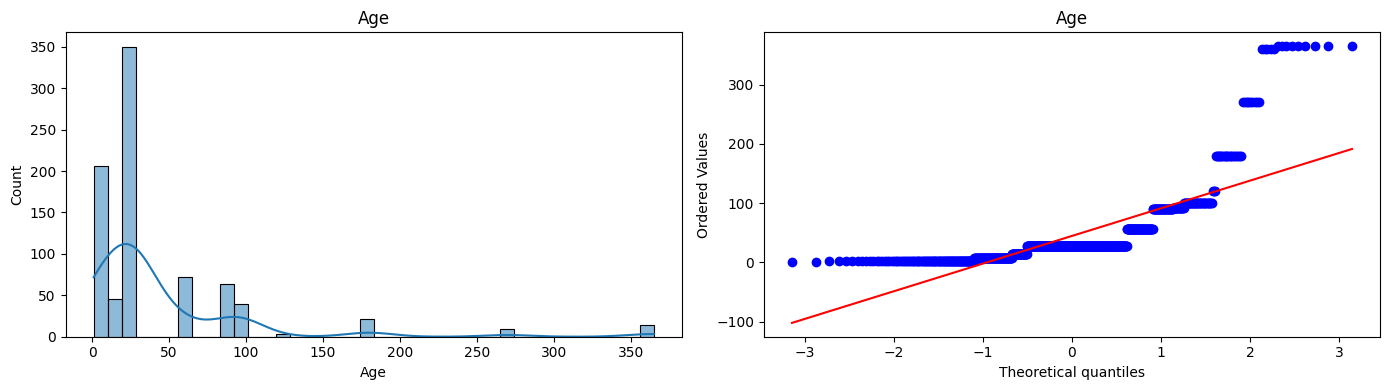

In [13]:
for col in X_train.columns :
  plt.figure(figsize=(14,4))
  plt.subplot(121)
  sns.histplot(X_train[col],kde=True)
  plt.title(col)

  plt.subplot(122)
  stats.probplot(X_train[col],dist="norm",plot=plt)
  plt.title(col)

  plt.tight_layout()
  plt.show()

## apply box-cox transform

In [14]:
pt = PowerTransformer(method='box-cox')

In [19]:
# Applying the Box-Cox Transform
# Now here I'll not be using standardized data because in Power Transfor there is already standardization is implemented on columns


X_train_transformed = pt.fit_transform(X_train + 0.000001)
X_test_transformed = pt.transform(X_test + 0.000001)

# Here I am adding 0.000001 because box- cox can't
#work with 0 values in data , so I am adding very
#very small values which
# is not going to change anything so much (read in a blog)


## check lambda value

In [20]:
X_train_transformed = pd.DataFrame(
    X_train_transformed,
    columns=X_train.columns
)

X_test_transformed = pd.DataFrame(
    X_test_transformed,
    columns=X_test.columns
)

In [21]:
pd.DataFrame({
    'cols': X_train.columns,
    'box-cox_lambdas': pt.lambdas_
})

,cols,box-cox_lambdas
0,Cement,0.177025
1,Blast Furnace Slag,0.025093
2,Fly Ash,-0.038970
3,Water,0.772682
4,Superplasticizer,0.098811
5,Coarse Aggregate,1.129813
6,Fine Aggregate,1.782018
7,Age,0.066631


## plotting after transform

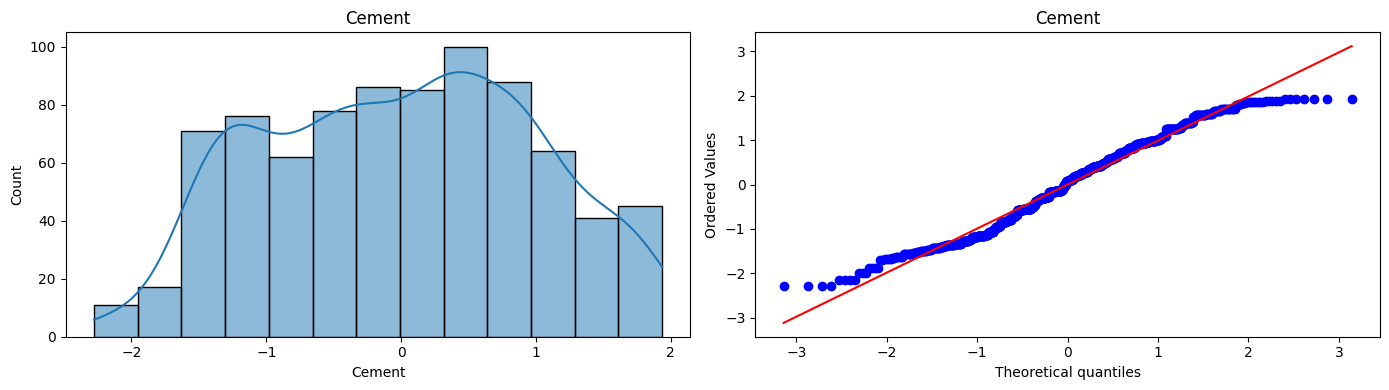

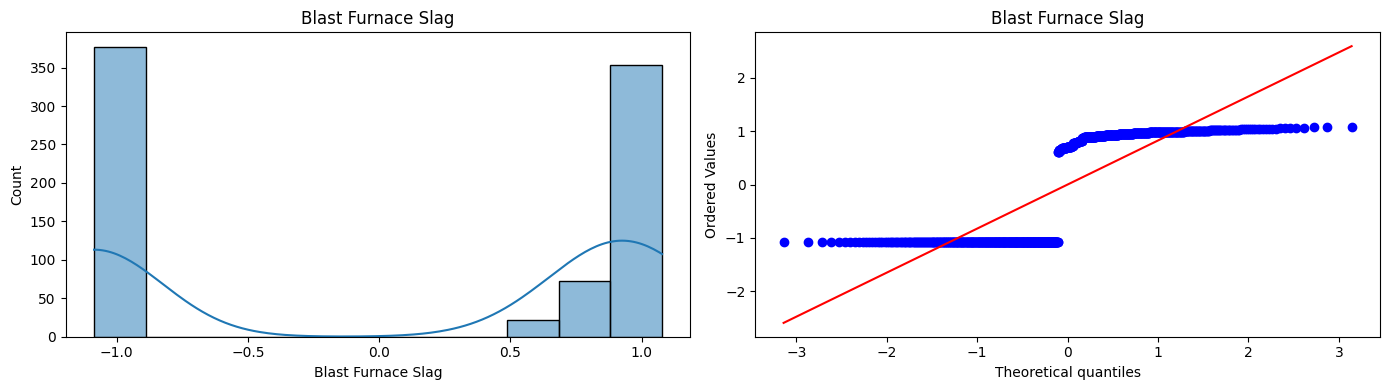

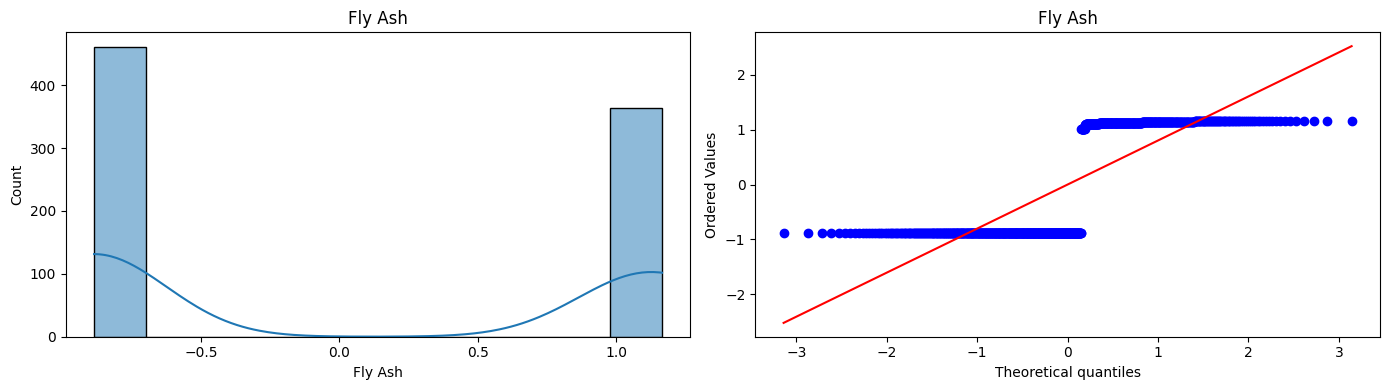

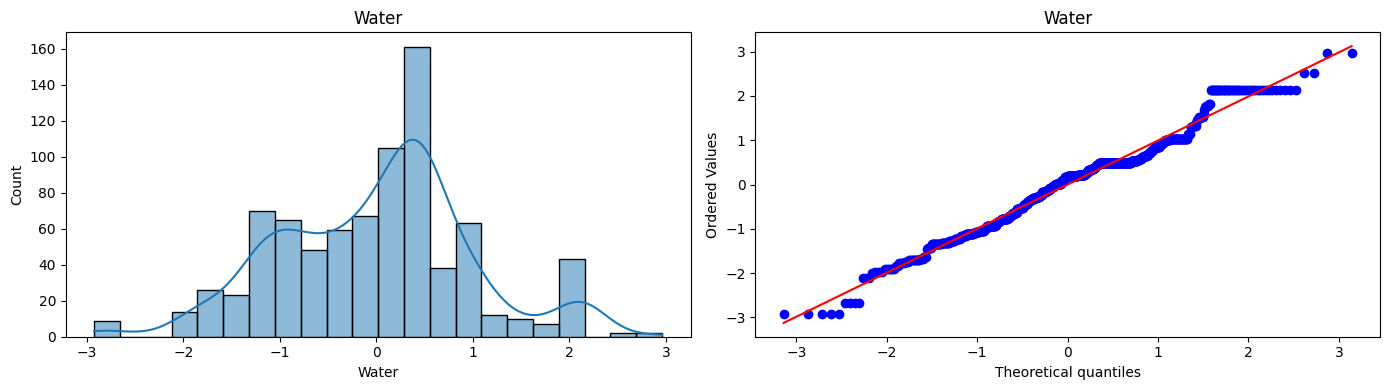

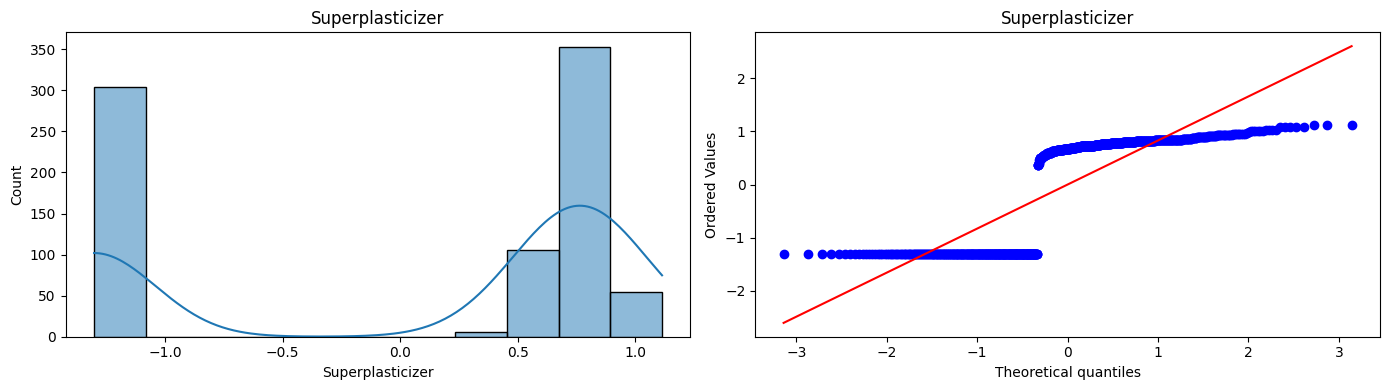

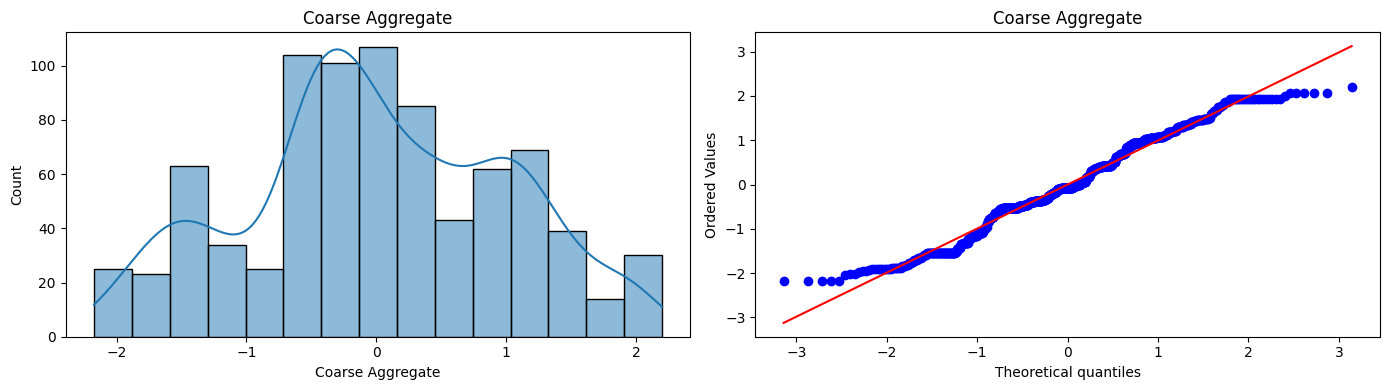

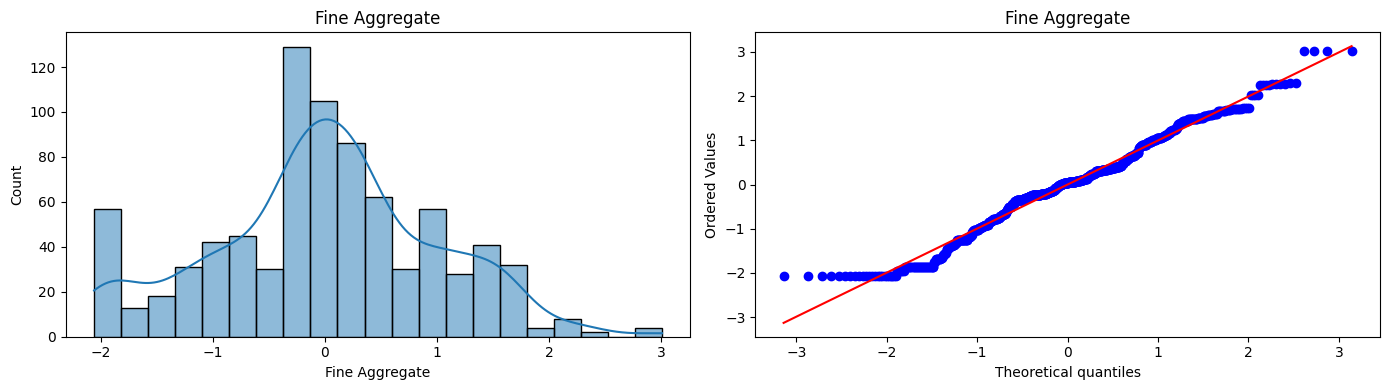

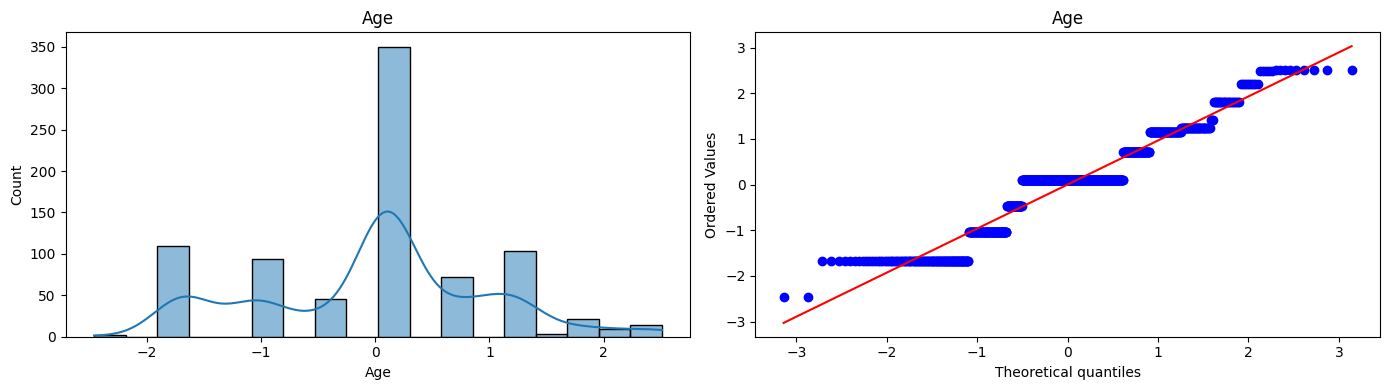

In [22]:
for col in X_train_transformed.columns:

    plt.figure(figsize=(14,4))

    # Histogram
    plt.subplot(121)
    sns.histplot(X_train_transformed[col], kde=True)
    plt.title(col)

    # QQ Plot
    plt.subplot(122)

    stats.probplot(X_train_transformed[col], dist="norm", plot=plt)
    plt.title(col)
    plt.tight_layout()
    plt.show()




# Yeo-Johnson

## visualize before transform

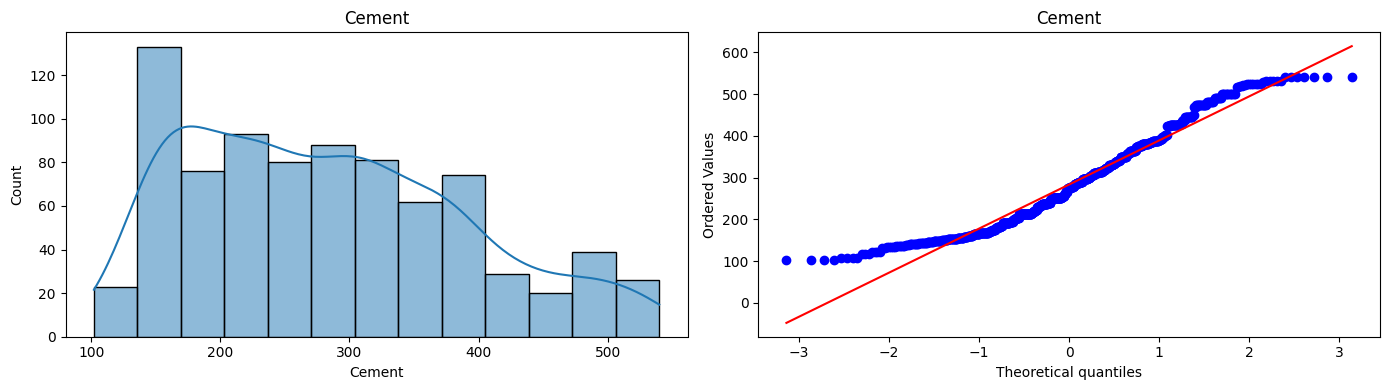

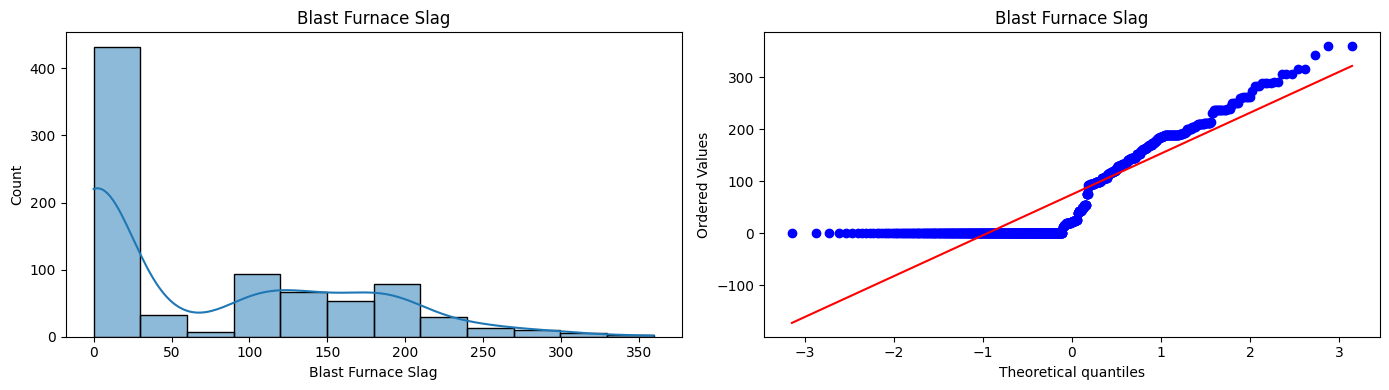

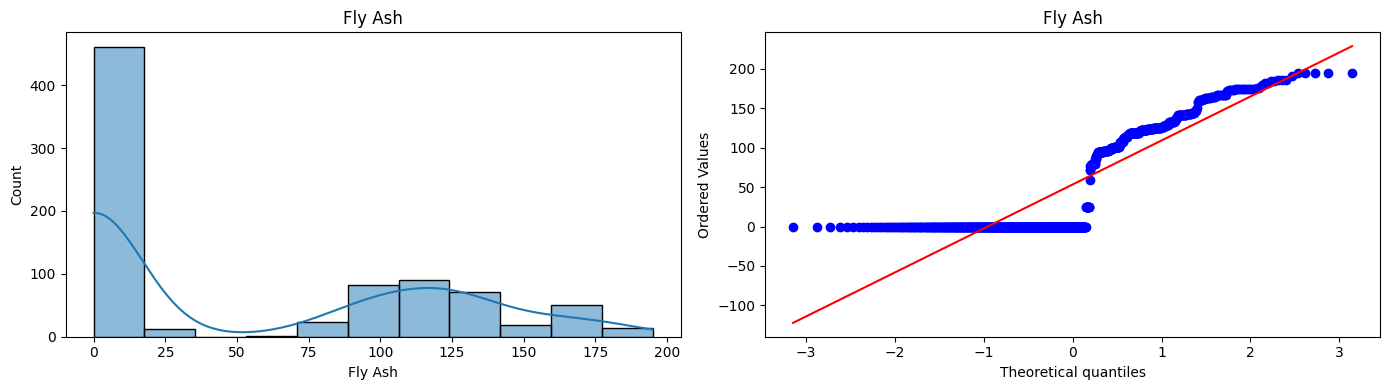

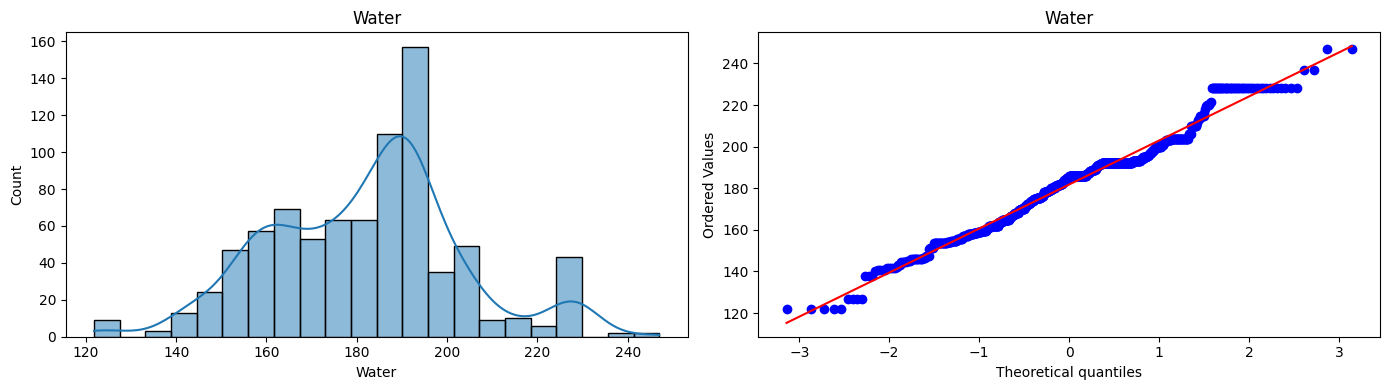

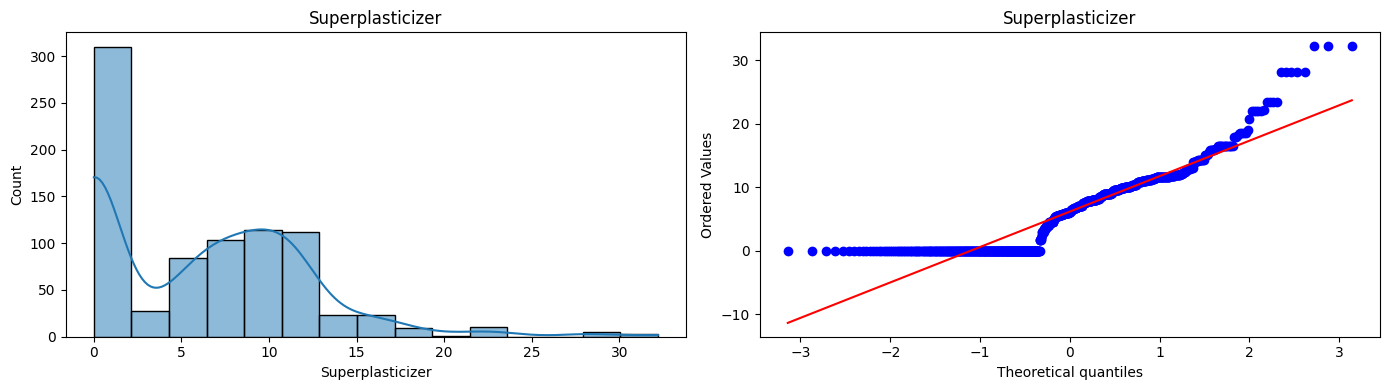

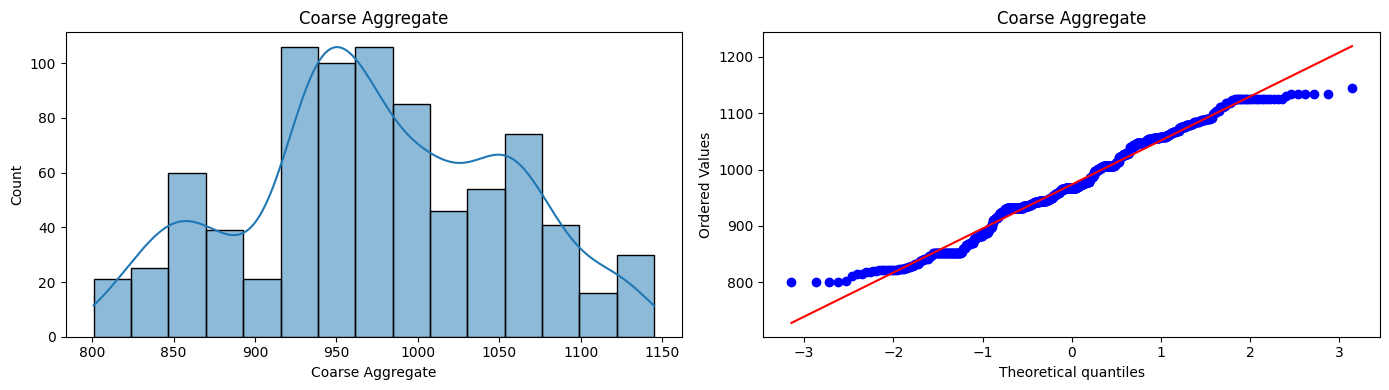

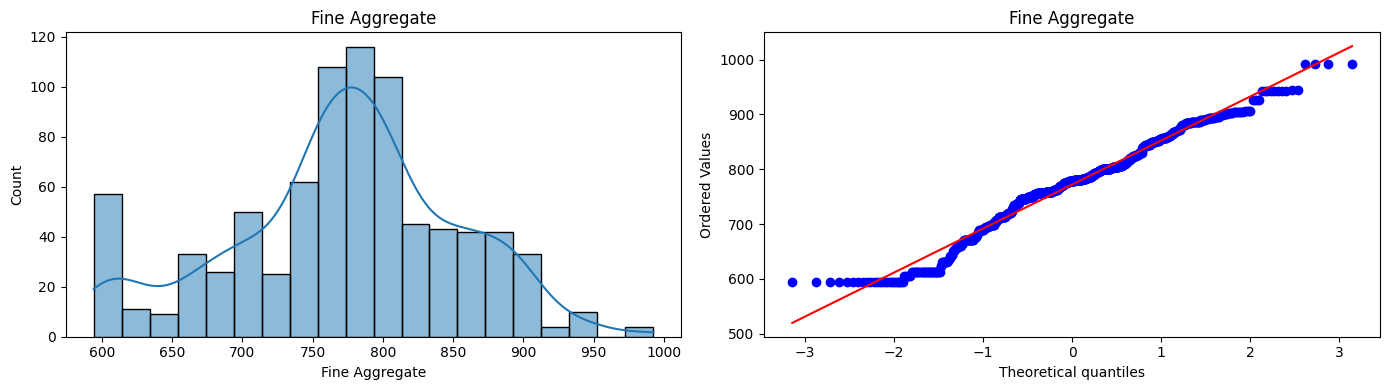

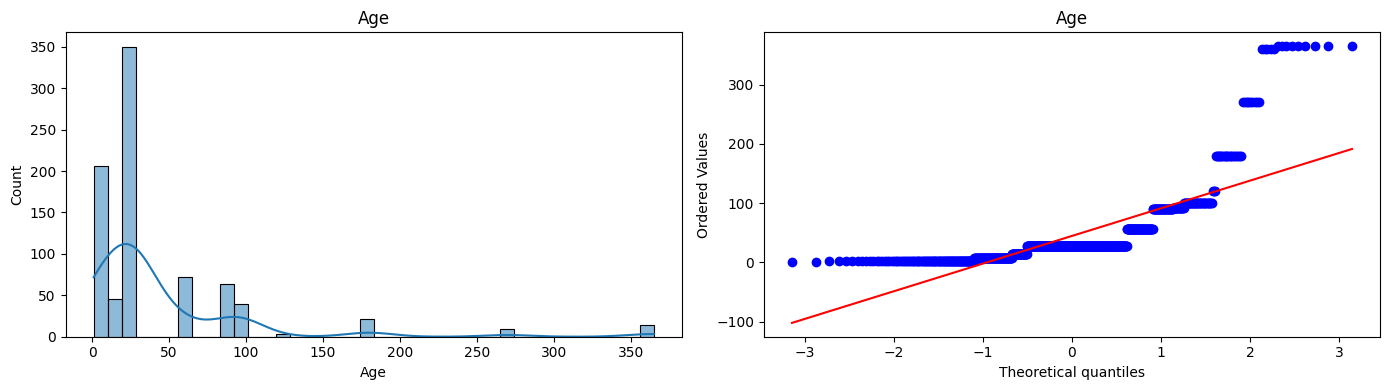

In [23]:
for col in X_train.columns :
  plt.figure(figsize=(14,4))
  plt.subplot(121)
  sns.histplot(X_train[col],kde=True)
  plt.title(col)

  plt.subplot(122)
  stats.probplot(X_train[col],dist="norm",plot=plt)
  plt.title(col)

  plt.tight_layout()
  plt.show()

## apply yeo-johnson

In [25]:
pt = PowerTransformer(method='yeo-johnson')

In [26]:
X_train_transformed_yeo = pt.fit_transform(X_train)

X_test_transformed_yeo = pt.transform(X_test)

## convert to dataframe

In [27]:
X_train_transformed = pd.DataFrame(
    X_train_transformed,
    columns=X_train.columns
)

X_test_transformed = pd.DataFrame(
    X_test_transformed,
    columns=X_test.columns
)

## check lambda

In [28]:
pd.DataFrame({
    'cols': X_train.columns,
    'YeoJohnson_lambdas': pt.lambdas_
})

,cols,YeoJohnson_lambdas
0,Cement,0.174348
1,Blast Furnace Slag,0.015715
2,Fly Ash,-0.161447
3,Water,0.771307
4,Superplasticizer,0.253935
5,Coarse Aggregate,1.130050
6,Fine Aggregate,1.783100
7,Age,0.019885


## Visualize after transformation

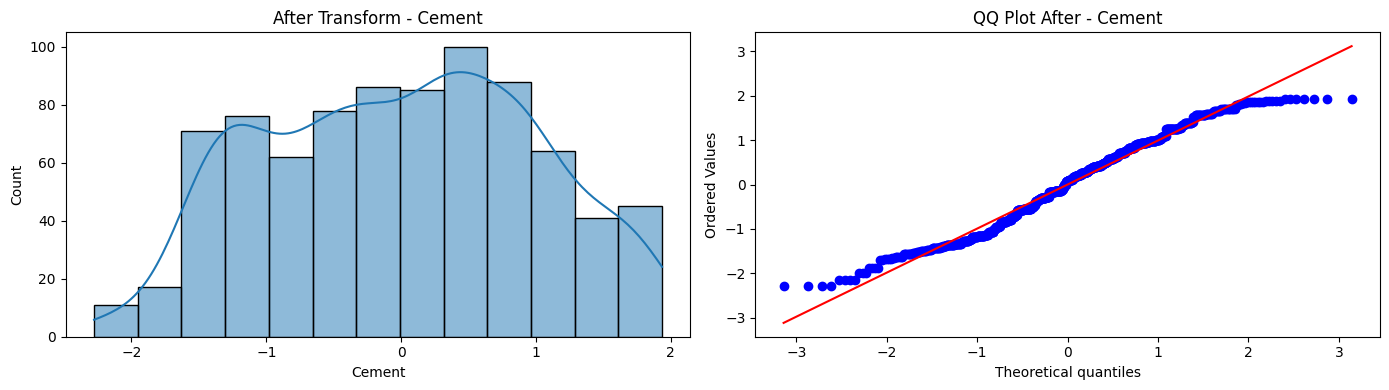

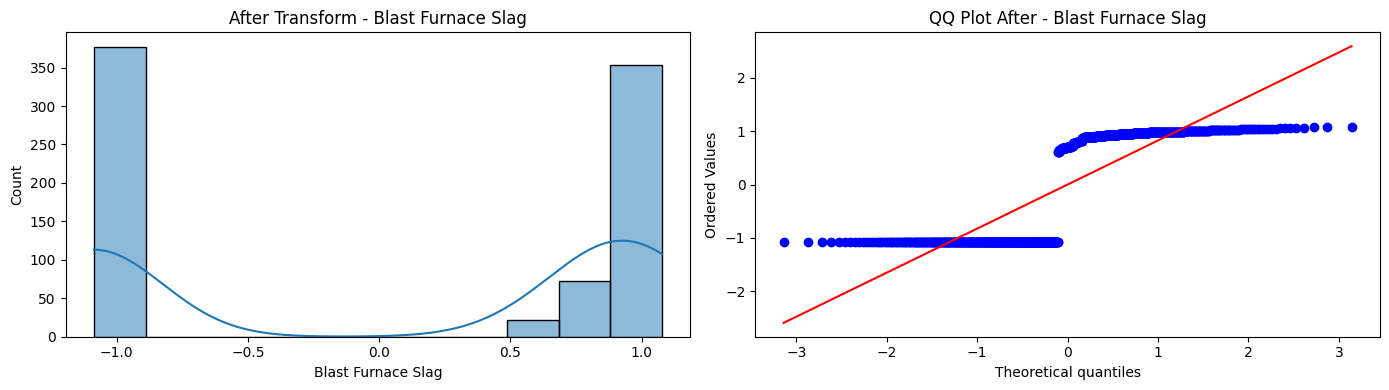

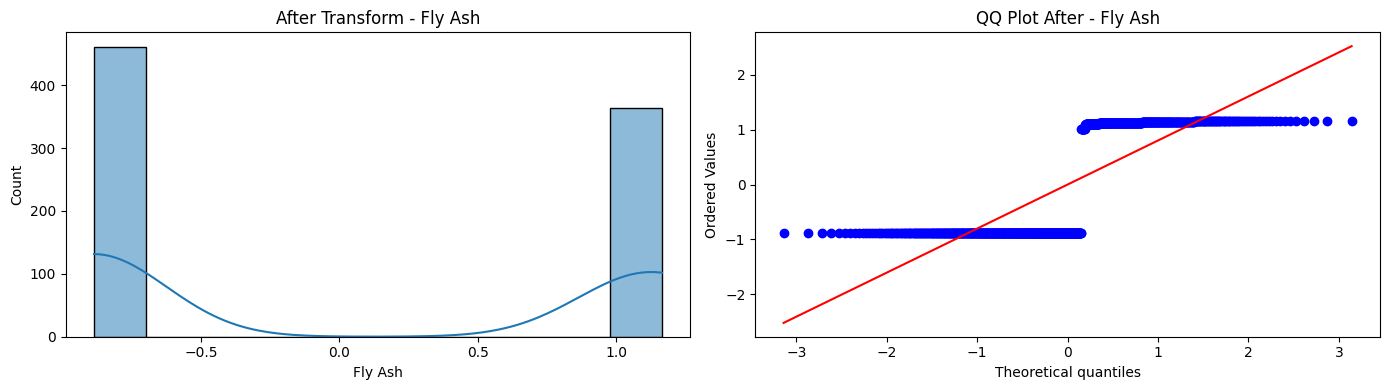

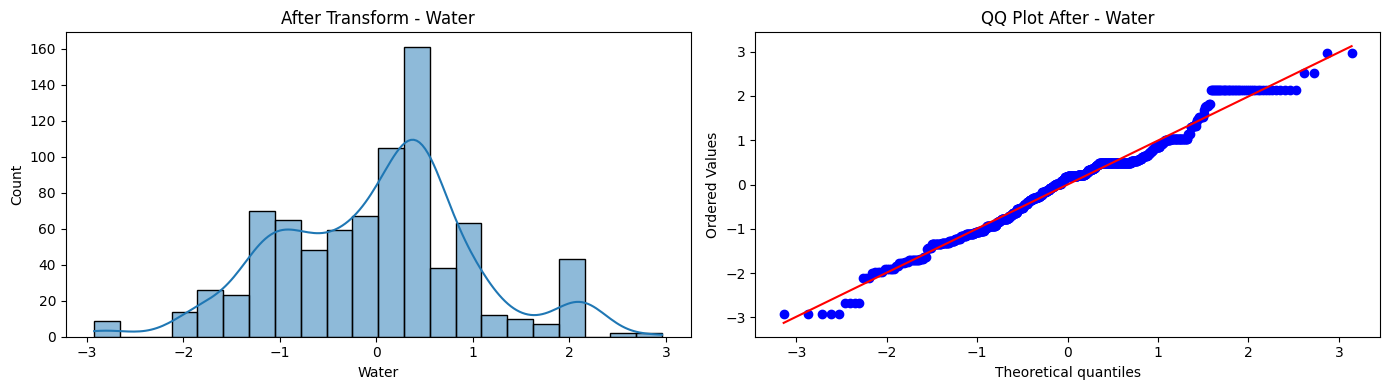

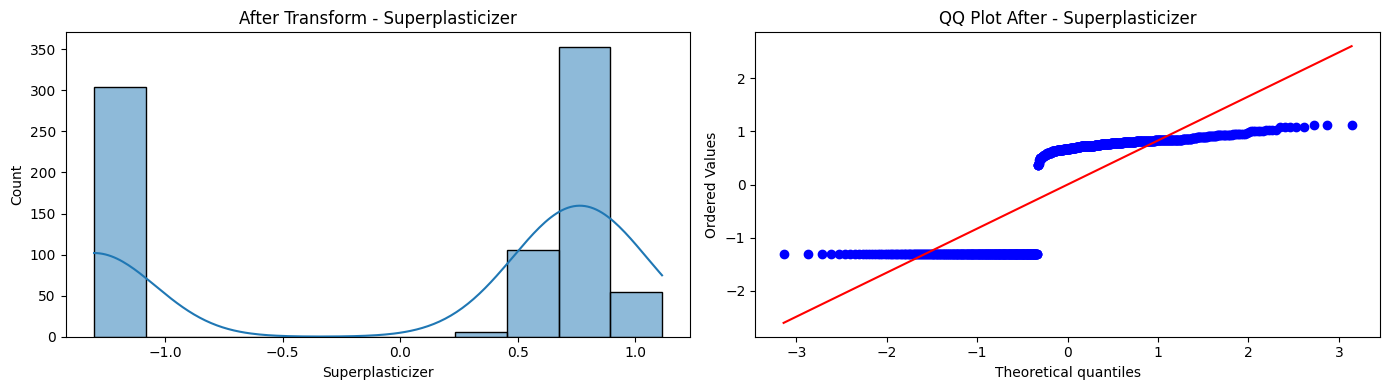

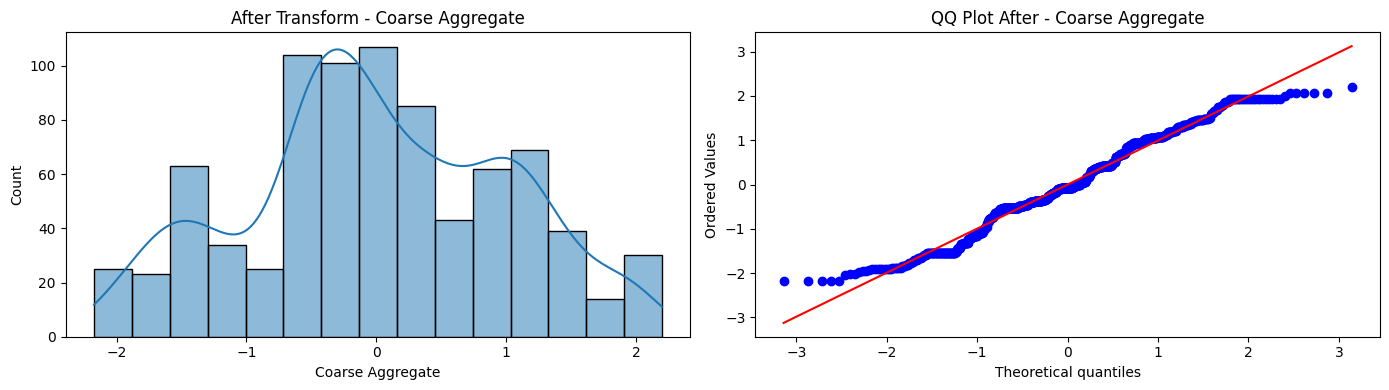

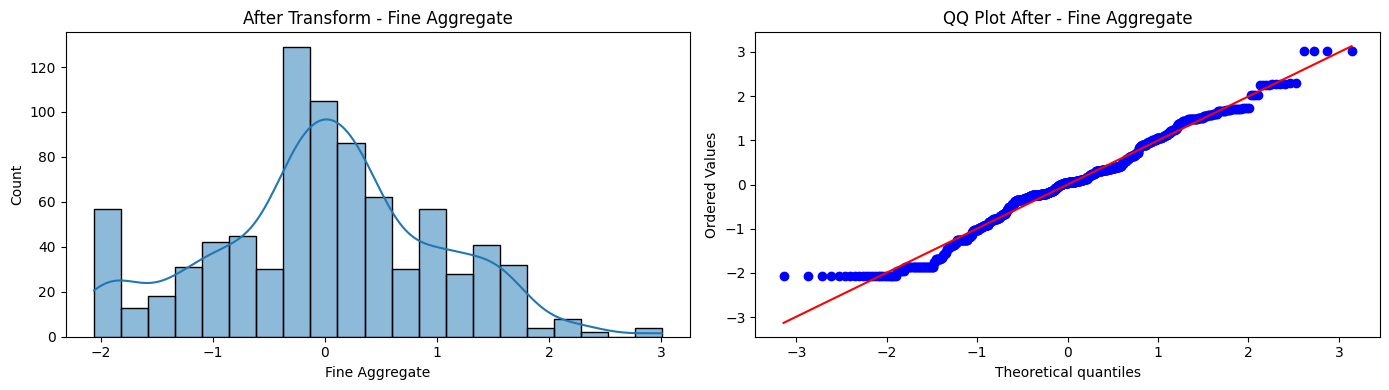

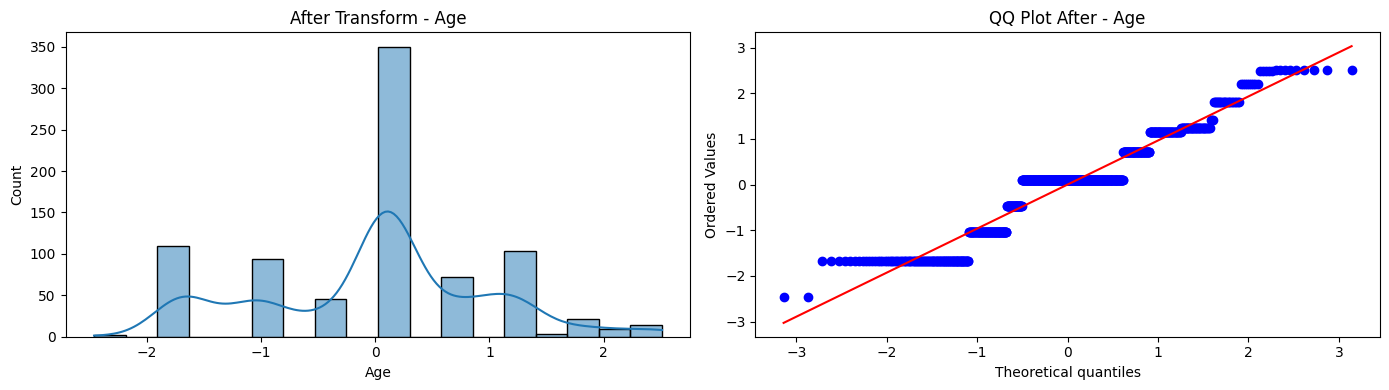

In [29]:
for col in X_train_transformed.columns:

    plt.figure(figsize=(14,4))

    # Histogram
    plt.subplot(121)

    sns.histplot(
        X_train_transformed[col],
        kde=True
    )

    plt.title(f'After Transform - {col}')

    # QQ Plot
    plt.subplot(122)

    stats.probplot(
        X_train_transformed[col],
        dist="norm",
        plot=plt
    )

    plt.title(f'QQ Plot After - {col}')

    plt.tight_layout()
    plt.show()